In [2]:
#!pip install numpy   # install numpy

#!pip install pandas matplotlib seaborn scikit-learn   # install multiple libraries at once

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install gspread gspread-dataframe   # install to connect to google sheets

print("Thank you")

Thank you


In [3]:
# copied export code from google sheets "sheets to collab" extension

import gspread
import pandas as pd
from google.auth import default
from google.colab import auth, userdata
spreadsheet_id = userdata.get('SPREADSHEET_ID')

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
# Pull spreadsheet ID from Colab Secrets
spreadsheet = gc.open_by_key(spreadsheet_id)
worksheet = spreadsheet.get_worksheet(0)
df = pd.DataFrame(worksheet.get())
# Code for making the first row as header. Remove if not needed.
df.columns = df.iloc[0]
df = df.drop(0)
df.head()

,Student ID,Parent Name,Student Name,Family ID,Matched?,Notes,Calendly Recap,Service Vertical,Academic Strengths,Areas for Growth,Learning Style,Personality,Special Needs,Personal Interests,Attendance,Engagement,Trust Consultant,Trust Company
1,ST-uZFp9,PTA,STA,CL-fJyk0,1,College consulting for competitive high school...,Summary\nThe meeting focused on planning and s...,College Planning,"Math, Science","History/Social Studies, Foreign Languages","Kinesthetic, Visual, Social, Independent","Independent, Problem Solver, Creative","General Anxiety, Perfectionism, Gifted","Volleyball, Reading/Book Clubs",100%,2.5,5,5
2,ST-2,PTB,STB,CL-8RWzo,1,School: New York area\nSubject: 10th grade Geo...,Summary\nThe meeting focused on arranging urge...,,,,,,,,91%,5,5,5
3,ST-1,PTC,STC,CL-eVVl8,1,"Grade: Junior (11th grade), Panther Creek High...",,,,,,,,,71%,5,5,5
4,ST-3,PTD,STD,CL-S0oiT,1,student has anxiety and adhd; the connection t...,,,,,,,,,63%,3,5,5
5,ST-jPyn5,PTE,STE,CL-3RaJa,1,Wants to be higher than where she's at\nACT 21...,Summary\nThe meeting focused on planning acade...,Tutoring & College Prep,English/Language Arts,Math,Visual,"Active Explorer, Independent, Social Connector",Not Applicable,Cheerleading,86%,5,3,4


In [4]:
insight = gc.open('Tutor Matching Public')   # open & rename spreadsheet

# open & rename specific worksheets in spreadsheet
students = insight.worksheet('Students')

studentsdf = pd.DataFrame(students.get_all_values())
#studentsdf.head()  # I see here that the first row of data is actually the columns.
# To fix:
studentsdf.columns = studentsdf.iloc[0]
studentsdf = studentsdf.iloc[1:].reset_index(drop=True)

studentsdf.head()

,Student ID,Parent Name,Student Name,Family ID,Matched?,Notes,Calendly Recap,Service Vertical,Academic Strengths,Areas for Growth,Learning Style,Personality,Special Needs,Personal Interests,Attendance,Engagement,Trust Consultant,Trust Company
0,ST-uZFp9,PTA,STA,CL-fJyk0,1,College consulting for competitive high school...,Summary\nThe meeting focused on planning and s...,College Planning,"Math, Science","History/Social Studies, Foreign Languages","Kinesthetic, Visual, Social, Independent","Independent, Problem Solver, Creative","General Anxiety, Perfectionism, Gifted","Volleyball, Reading/Book Clubs",100%,2.5,5,5
1,ST-2,PTB,STB,CL-8RWzo,1,School: New York area\nSubject: 10th grade Geo...,Summary\nThe meeting focused on arranging urge...,,,,,,,,91%,5,5,5
2,ST-1,PTC,STC,CL-eVVl8,1,"Grade: Junior (11th grade), Panther Creek High...",,,,,,,,,71%,5,5,5
3,ST-3,PTD,STD,CL-S0oiT,1,student has anxiety and adhd; the connection t...,,,,,,,,,63%,3,5,5
4,ST-jPyn5,PTE,STE,CL-3RaJa,1,Wants to be higher than where she's at\nACT 21...,Summary\nThe meeting focused on planning acade...,Tutoring & College Prep,English/Language Arts,Math,Visual,"Active Explorer, Independent, Social Connector",Not Applicable,Cheerleading,86%,5,3,4


In [5]:
# open & rename specific worksheets in spreadsheet
tutors = insight.worksheet('Tutors')

tutorsdf = pd.DataFrame(tutors.get_all_values())

tutorsdf.columns = tutorsdf.iloc[0]
tutorsdf = tutorsdf.iloc[1:].reset_index(drop=True)

tutorsdf.head()

,Tutor ID,Tutor Name,Service Vertical,Expertise,Special Skills,Interests,Introductions,Attendance,Professionalism Score,Survey Completion,Match Confidence,Emotional Energy,Support Load,Goal Alignment
0,TM-TL79Z,TMA,"Generalist, College Admissions","Math (K-8), Geometry, Trigonometry, Precalculu...","ADHD, Autism, Generalized Anxiety",Worked in Behavioral Therapy,From Team Chat: I graduated from UCLA with a m...,58%,25,30%,5,5,2,5
1,TM-d4VRd,TMB,"College Admissions, Test Prep","College Planning, Study Skills/Executive Funct...","ADHD, Autism",,From Team Chat: I graduated from University o...,71%,14,0%,2,1,5,2
2,TM-1A6Pu,TMC,"College Admissions, K-12 Tutoring","Study Skills/Executive Function, Interview Pre...",,,Has Bachelor’s Degree in Healthcare mgmt & pol...,69%,12,63%,3,3,5,2
3,TM-OIOgR,TMD,"Generalist, College Admissions",,"ADHD, Dyslexia/Dyscalculia/Dysgraphia, Executi...","ADHD, Dyslexia, Dyscalculia, Dysgraphia, Execu...",,84%,17,80%,NaN,NaN,NaN,NaN
4,TM-3ZXLA,TME,K-12 Tutoring,,,,"I was originally born in NJ, but relocated to ...",75%,18,14%,4,5,2,4.5


In [6]:
# open & rename specific worksheets in spreadsheet
assignments = insight.worksheet('Assignments')

assignmentsdf = pd.DataFrame(assignments.get_all_values())

assignmentsdf.columns = assignmentsdf.iloc[0]
assignmentsdf = assignmentsdf.iloc[1:].reset_index(drop=True)

assignmentsdf.head()

,Assignment ID,Assignment Name,Student ID,Tutor ID,Start Date,Match Logic,Academic Goals,Emotional Energy,Support Load,Goal Alignment,Match Confidence,Total Hours,Engagement,Consultant Rating,Company Rating,Confidence
0,ASMT-e9SaK,STE-TME,ST-jPyn5,TM-3ZXLA,5/27/2026,,Wanting to raise her ACT score from around a 2...,4,4,5,4,7.25,5,3,4,3
1,ASMT-xxiCO,STH-TMF,ST-OVf76,TM-iAkig,6/23/2026,is very strong with test prep and STEM subject...,Prepare for the July 8 ISEE through deep conce...,5,5,5,5,4,,,,
2,ASMT-ggGtu,STG-TMA,ST-TBhk6,TM-TL79Z,6/16/2026,expressed confidence in being able to do colle...,"Complete a strong, authentic Common App essay ...",4.5,5,5,5,2,5,,,
3,ASMT-wnXLK,STC-TMB,ST-1,TM-d4VRd,5/8/2026,,"Support with overall academic motivation, exec...",NaN,NaN,NaN,NaN,5,3,5,5,2
4,ASMT-BJarT,STA-TMG,ST-uZFp9,TM-JPPtB,4/22/2026,,Support and guidance on how to prepare for com...,4,3,4,4,2,2.5,5,5,5


In [7]:
# I want to check all of my dataframes
print(studentsdf.columns)
print(studentsdf.shape)

Index(['Student ID', 'Parent Name', 'Student Name', 'Family ID', 'Matched?',
       'Notes', 'Calendly Recap', 'Service Vertical', 'Academic Strengths',
       'Areas for Growth', 'Learning Style', 'Personality', 'Special Needs',
       'Personal Interests', 'Attendance', 'Engagement', 'Trust Consultant',
       'Trust Company'],
      dtype='object', name=0)
(26, 18)


In [8]:
print(tutorsdf.columns)
print(tutorsdf.shape)

Index(['Tutor ID', 'Tutor Name', 'Service Vertical', 'Expertise',
       'Special Skills', 'Interests', 'Introductions', 'Attendance',
       'Professionalism Score', 'Survey Completion', 'Match Confidence',
       'Emotional Energy', 'Support Load', 'Goal Alignment'],
      dtype='object', name=0)
(9, 14)


In [9]:
print(assignmentsdf.columns)
print(assignmentsdf.shape)

Index(['Assignment ID', 'Assignment Name', 'Student ID', 'Tutor ID',
       'Start Date', 'Match Logic', 'Academic Goals', 'Emotional Energy',
       'Support Load', 'Goal Alignment', 'Match Confidence', 'Total Hours',
       'Engagement', 'Consultant Rating', 'Company Rating', 'Confidence'],
      dtype='object', name=0)
(18, 16)


In [10]:
# For every assignment, attach the student information
matches = assignmentsdf.merge(
    studentsdf,
    on="Student ID",
    how="left"
)

# For every assignment, also attach the tutor information
matches = matches.merge(
    tutorsdf,
    on="Tutor ID",
    how="left"
)

print(matches.columns)
print(matches.shape)

Index(['Assignment ID', 'Assignment Name', 'Student ID', 'Tutor ID',
       'Start Date', 'Match Logic', 'Academic Goals', 'Emotional Energy_x',
       'Support Load_x', 'Goal Alignment_x', 'Match Confidence_x',
       'Total Hours', 'Engagement_x', 'Consultant Rating', 'Company Rating',
       'Confidence', 'Parent Name', 'Student Name', 'Family ID', 'Matched?',
       'Notes', 'Calendly Recap', 'Service Vertical_x', 'Academic Strengths',
       'Areas for Growth', 'Learning Style', 'Personality', 'Special Needs',
       'Personal Interests', 'Attendance_x', 'Engagement_y',
       'Trust Consultant', 'Trust Company', 'Tutor Name', 'Service Vertical_y',
       'Expertise', 'Special Skills', 'Interests', 'Introductions',
       'Attendance_y', 'Professionalism Score', 'Survey Completion',
       'Match Confidence_y', 'Emotional Energy_y', 'Support Load_y',
       'Goal Alignment_y'],
      dtype='object', name=0)
(18, 46)


In [11]:
# It does look like we retained all our columns but only have 18 records

# studentsdf should now have all the students with assignments
matches[["Student ID", "Student Name"]]

,Student ID,Student Name
0,ST-jPyn5,STE
1,ST-OVf76,STH
2,ST-TBhk6,STG
3,ST-1,STC
4,ST-uZFp9,STA
5,ST-9rEFo,STM
6,ST-9pMB3,STL
7,ST-sc7Ma,STO
8,ST-RQxAU,STJ
9,ST-tCCRu,STK


In [12]:
# We want to create Student Clusters for comparison, and I want to use NLP to
# create one "profile" to analyze each student.

# fillna to clean students data

studentsdf["StudentProfile"] = (
    studentsdf["Notes"].fillna("") + " " +
    studentsdf["Calendly Recap"].fillna("") + " " +
    studentsdf["Areas for Growth"].fillna("") + " " +
    studentsdf["Learning Style"].fillna("") + " " +
    studentsdf["Personality"].fillna("") + " " +
    studentsdf["Special Needs"].fillna("") + " " +
    studentsdf["Personal Interests"].fillna("")
)

studentsdf[["Student Name", "StudentProfile"]].sample(1)

,Student Name,StudentProfile
12,STM,"top choices: BU (like city the and pre-med), U..."


In [13]:
# Give me a list of the students who did NOT get joined bc they did not have an assignment

studentsdf["Student ID"].isin(assignmentsdf["Student ID"])

studentsb = studentsdf[
    ~studentsdf["Student ID"].isin(assignmentsdf["Student ID"])
].copy()

studentsb[["Student ID", "Student Name","StudentProfile"]]

,Student ID,Student Name,StudentProfile
18,ST-hp4cB,STS,10th grader with English classes. Taking her r...
19,ST-5,STT,Student has always been a decent studentStrugg...
20,ST-6,STU,"8th grader, ADHD on a nonstimulant medication,..."
21,ST7,STV,Student is a sophomore (rising junior) who has...
22,ST-8,STW,9th grade student; multiple subject long-term ...
23,ST-9,STX,ACT support for 10th grader; Student has taken...
24,ST-10,STY,1-hr once a week tutoring session for rising 3...
25,ST-11,STZ,"college consultant for her 15-year-old son, a ..."


In [14]:
# Clean tutors data

tutorsdf["TutorProfile"] = (
    tutorsdf["Expertise"].fillna("") + " " +
    tutorsdf["Special Skills"].fillna("") + " " +
    tutorsdf["Interests"].fillna("") + " " +
    tutorsdf["Introductions"].fillna("")
)

tutorsdf[["Tutor Name", "TutorProfile"]].sample(1)

,Tutor Name,TutorProfile
6,TMG,"SAT/ACT Prep, AP Exam Prep (General), Physics,..."


#NLP   TF-IDF

##Term Frequency-Inverse Document Frequency


In [15]:
# We'll find the most important words (relatively) for each profile and
# compare student and tutor descriptions (using similarity measures later)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500
)


student_vectors = vectorizer.fit_transform(
    studentsdf["StudentProfile"]
)

student_vectors.shape

(26, 500)

In [16]:
vectorizer.get_feature_names_out()

array(['10', '100', '10th', '15', '25', '30', '45', '4th', '50', '60',
       '8th', 'ability', 'academic', 'academically', 'accommodate',
       'accountability', 'act', 'acting', 'action', 'activities', 'adapt',
       'additional', 'address', 'addressing', 'adhd', 'adjust',
       'admissions', 'advisor', 'advocacy', 'agency', 'agreed',
       'agreement', 'ai', 'aiming', 'aims', 'align', 'allowing',
       'anxiety', 'ap', 'applicable', 'application', 'applications',
       'approach', 'approaches', 'areas', 'arts', 'athletic', 'attending',
       'auditory', 'availability', 'available', 'avoid', 'background',
       'backgrounds', 'backup', 'balance', 'balancing', 'baseball',
       'based', 'basketball', 'behavioral', 'best', 'better', 'biology',
       'bit', 'brother', 'build', 'building', 'burnout', 'business',
       'busy', 'care', 'career', 'centers', 'challenge', 'challenges',
       'change', 'check', 'chemistry', 'children', 'circles', 'class',
       'classes', 'club', 

In [17]:
import pandas as pd

student_tfidf = pd.DataFrame(
    student_vectors.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=studentsdf["Student Name"]
)

student_tfidf.head()

,10,100,10th,15,25,30,45,4th,50,60,...,week,weekends,weekly,wellness,willing,work,working,writing,year,years
Student Name,,,,,,,,,,,,,,,,,,,,,
STA,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.037337,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034327,0.0
STB,0.000000,0.0,0.023789,0.0,0.000000,0.023789,0.0,0.0,0.000000,0.0,...,0.083860,0.0,0.000000,0.076853,0.027195,0.000000,0.000000,0.000000,0.046261,0.0
STC,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.189167,0.0,0.000000,0.000000,0.000000,0.000000,0.253063,0.000000,0.000000,0.0
STD,0.000000,0.0,0.363526,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.342869,0.000000,0.000000,0.0
STE,0.034173,0.0,0.000000,0.0,0.037011,0.029893,0.0,0.0,0.040671,0.0,...,0.063226,0.0,0.074022,0.024143,0.034173,0.025355,0.028194,0.050711,0.000000,0.0


In [18]:
tutor_vectors = vectorizer.transform(
    tutorsdf["TutorProfile"]
)

tutor_vectors.shape

(9, 500)

In [19]:
tutor_tfidf = pd.DataFrame(
    tutor_vectors.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=tutorsdf["Tutor Name"]
)

tutor_tfidf.head()

,10,100,10th,15,25,30,45,4th,50,60,...,week,weekends,weekly,wellness,willing,work,working,writing,year,years
Tutor Name,,,,,,,,,,,,,,,,,,,,,
TMA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.150384,0.083610,0.075192,0.114924,0.0
TMB,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.162911,0.090574,0.081455,0.000000,0.0
TMC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.093192,0.142435,0.0
TMD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0
TME,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Compare every student to every tutor
similarity = cosine_similarity(
    student_vectors,
    tutor_vectors
)

similarity.shape

(26, 9)

Cool.

In [21]:
# Turn the matrix into a dataframe

similarity_df = pd.DataFrame(
    similarity,
    index=studentsdf["Student Name"],
    columns=tutorsdf["Tutor Name"]
)

similarity_df.head()

Tutor Name,TMA,TMB,TMC,TMD,TME,TMF,TMG,TMH,TMI
Student Name,,,,,,,,,
STA,0.129213,0.111624,0.176210,0.081608,0.000000,0.067850,0.144581,0.042080,0.126804
STB,0.208898,0.174133,0.249618,0.154473,0.000000,0.136233,0.230660,0.097190,0.195243
STC,0.143015,0.154686,0.147895,0.041059,0.052593,0.024715,0.178467,0.019229,0.071098
STD,0.166269,0.159535,0.023550,0.300639,0.000000,0.218055,0.280137,0.093938,0.022372
STE,0.215892,0.207083,0.264931,0.096284,0.011719,0.039417,0.230316,0.178370,0.175875


In [22]:
# Quick check on what this looks like for one student

similarity_df.loc["STE"].sort_values(ascending=False)

,STE
Tutor Name,
TMC,0.264931
TMG,0.230316
TMA,0.215892
TMB,0.207083
TMH,0.178370
TMI,0.175875
TMD,0.096284
TMF,0.039417
TME,0.011719


This answers the question, "Based on the information in their profiles, which tutors look most similar to what this student needs?"

In [23]:
# Apply to studentsb
studentsb_vectors = vectorizer.transform(
    studentsb["StudentProfile"]
)
studentsb_similarity = cosine_similarity(
    studentsb_vectors,
    tutor_vectors
)
studentsb_similarity_df = pd.DataFrame(
    studentsb_similarity,
    index=studentsb["Student Name"],
    columns=tutorsdf["Tutor Name"]
)

studentsb_similarity_df.head()

Tutor Name,TMA,TMB,TMC,TMD,TME,TMF,TMG,TMH,TMI
Student Name,,,,,,,,,
STS,0.175771,0.144444,0.227336,0.042287,0.051332,0.030742,0.179174,0.225102,0.208475
STT,0.206822,0.176406,0.220715,0.131438,0.009665,0.086937,0.315411,0.151491,0.176912
STU,0.234815,0.175217,0.238520,0.199401,0.000000,0.048096,0.266025,0.105291,0.133649
STV,0.302163,0.253912,0.317437,0.245429,0.000000,0.061107,0.282230,0.121315,0.220876
STW,0.206176,0.311127,0.256666,0.022321,0.051987,0.030165,0.179533,0.032833,0.217903


In [24]:
similarity_df.loc["STZ"].sort_values(ascending=False)

,STZ
Tutor Name,
TMC,0.204137
TMG,0.180223
TMB,0.169032
TMA,0.166556
TMI,0.120561
TMD,0.069494
TMH,0.043769
TMF,0.037007
TME,0.032642


In [25]:
# So this gives me similarity for all students and tutors:
print(similarity_df)

Tutor Name         TMA       TMB       TMC       TMD       TME       TMF  \
Student Name                                                               
STA           0.129213  0.111624  0.176210  0.081608  0.000000  0.067850   
STB           0.208898  0.174133  0.249618  0.154473  0.000000  0.136233   
STC           0.143015  0.154686  0.147895  0.041059  0.052593  0.024715   
STD           0.166269  0.159535  0.023550  0.300639  0.000000  0.218055   
STE           0.215892  0.207083  0.264931  0.096284  0.011719  0.039417   
STF           0.079097  0.064818  0.096830  0.019729  0.000000  0.084300   
STG           0.151280  0.127787  0.152534  0.047844  0.058779  0.069600   
STH           0.105996  0.070312  0.074948  0.068595  0.079108  0.016768   
STI           0.243599  0.187278  0.265361  0.070947  0.020102  0.086257   
STJ           0.275668  0.224085  0.311264  0.102618  0.048711  0.078792   
STK           0.099332  0.096261  0.175455  0.015093  0.000000  0.000000   
STL         

In [26]:
# and this gives me similarity for all unmatched students:
print(studentsb_similarity_df)

Tutor Name         TMA       TMB       TMC       TMD       TME       TMF  \
Student Name                                                               
STS           0.175771  0.144444  0.227336  0.042287  0.051332  0.030742   
STT           0.206822  0.176406  0.220715  0.131438  0.009665  0.086937   
STU           0.234815  0.175217  0.238520  0.199401  0.000000  0.048096   
STV           0.302163  0.253912  0.317437  0.245429  0.000000  0.061107   
STW           0.206176  0.311127  0.256666  0.022321  0.051987  0.030165   
STX           0.230024  0.177589  0.284592  0.080555  0.131859  0.086417   
STY           0.170316  0.163635  0.281818  0.156933  0.009343  0.035683   
STZ           0.166556  0.169032  0.204137  0.069494  0.032642  0.037007   

Tutor Name         TMG       TMH       TMI  
Student Name                                
STS           0.179174  0.225102  0.208475  
STT           0.315411  0.151491  0.176912  
STU           0.266025  0.105291  0.133649  
STV           

In [27]:
# Top 3 tutors for every unmatched student (studentsb)
top3_studentsb = (
    studentsb_similarity_df
    .apply(lambda row: row.sort_values(ascending=False).head(3), axis=1)
)

top3_studentsb

Tutor Name,TMA,TMB,TMC,TMG,TMH,TMI
Student Name,,,,,,
STS,NaN,NaN,0.227336,NaN,0.225102,0.208475
STT,0.206822,NaN,0.220715,0.315411,NaN,NaN
STU,0.234815,NaN,0.238520,0.266025,NaN,NaN
STV,0.302163,NaN,0.317437,0.282230,NaN,NaN
STW,NaN,0.311127,0.256666,NaN,NaN,0.217903
STX,0.230024,NaN,0.284592,0.277303,NaN,NaN
STY,0.170316,NaN,0.281818,0.212969,NaN,NaN
STZ,NaN,0.169032,0.204137,0.180223,NaN,NaN


In [28]:
def get_top_tutors(similarity_dataframe, top_n=3):
    recommendations = []

    for student_name, row in similarity_dataframe.iterrows():
        top_tutors = row.sort_values(ascending=False).head(top_n)

        for rank, (tutor_name, score) in enumerate(top_tutors.items(), start=1):
            recommendations.append({
                "Student Name": student_name,
                "Rank": rank,
                "Tutor Name": tutor_name,
                "Similarity Score": score
            })

    return pd.DataFrame(recommendations)

top3_all_students = get_top_tutors(similarity_df, top_n=3)
top3_studentsb = get_top_tutors(studentsb_similarity_df, top_n=3)

top3_all_students.head(15)

,Student Name,Rank,Tutor Name,Similarity Score
0,STA,1,TMC,0.176210
1,STA,2,TMG,0.144581
2,STA,3,TMA,0.129213
3,STB,1,TMC,0.249618
4,STB,2,TMG,0.230660
5,STB,3,TMA,0.208898
6,STC,1,TMG,0.178467
7,STC,2,TMB,0.154686
8,STC,3,TMC,0.147895
9,STD,1,TMD,0.300639


In [29]:
def top_tutors_wide(similarity_df, top_n=3):
    rows = []

    for student, scores in similarity_df.iterrows():
        top = scores.sort_values(ascending=False).head(top_n)

        row = {"Student": student}

        for i, tutor in enumerate(top.index, start=1):
            row[f"{i}st Match" if i == 1 else f"{i}nd Match" if i == 2 else f"{i}rd Match"] = tutor

        rows.append(row)

    return pd.DataFrame(rows)

top3 = top_tutors_wide(similarity_df)

top3.head()

,Student,1st Match,2nd Match,3rd Match
0,STA,TMC,TMG,TMA
1,STB,TMC,TMG,TMA
2,STC,TMG,TMB,TMC
3,STD,TMD,TMG,TMF
4,STE,TMC,TMG,TMA


In [30]:
print(top3)

   Student 1st Match 2nd Match 3rd Match
0      STA       TMC       TMG       TMA
1      STB       TMC       TMG       TMA
2      STC       TMG       TMB       TMC
3      STD       TMD       TMG       TMF
4      STE       TMC       TMG       TMA
5      STF       TMC       TMH       TMG
6      STG       TMI       TMC       TMA
7      STH       TMI       TMA       TME
8      STI       TMC       TMA       TMB
9      STJ       TMC       TMA       TMH
10     STK       TMC       TMI       TMA
11     STL       TMD       TMI       TMA
12     STM       TMF       TMH       TMI
13     STN       TMH       TMI       TMG
14     STO       TMH       TMF       TMI
15     STP       TMH       TMF       TMG
16     STQ       TMG       TMH       TMC
17     STR       TMH       TMI       TMC
18     STS       TMC       TMH       TMI
19     STT       TMG       TMC       TMA
20     STU       TMG       TMC       TMA
21     STV       TMC       TMA       TMG
22     STW       TMB       TMC       TMI
23     STX      

In [31]:
top3_unmatched = top_tutors_wide(studentsb_similarity_df)

top3_unmatched

,Student,1st Match,2nd Match,3rd Match
0,STS,TMC,TMH,TMI
1,STT,TMG,TMC,TMA
2,STU,TMG,TMC,TMA
3,STV,TMC,TMA,TMG
4,STW,TMB,TMC,TMI
5,STX,TMC,TMG,TMA
6,STY,TMC,TMG,TMA
7,STZ,TMC,TMG,TMB


# Clustering

So far we have answered the question,
> Which tutor profiles & student profiles are most similar in text?

Clustering will ask,
> What types of students naturally appear in this dataset based on similarities in their profiles?

Unlike classification, clustering does not use predefined outcome labels. I plan to build a supervised classification model in a separate branch. For this analysis, I want to see what patterns emerge from the student profiles alone.

It is also worth noting that this dataset is small.


In [32]:
X_students = student_vectors

print("Number of students:", X_students.shape[0])
print("Number of TF-IDF features:", X_students.shape[1])

Number of students: 26
Number of TF-IDF features: 500


So the resulting clusters should be interpreted as exploratory segments rather than validated student classifications.

Here, instead of comparing students to tutors, we're comparing them to each other. We'll set up those tables and then use K-means to divide observations into a number of groups by assigning each observation to the nearest cluster center.

In [34]:
# Create a clean lookup table so cluster assignments can be
# connected back to each student.

student_cluster_results = studentsdf[
    ["Student ID", "Student Name", "StudentProfile"]
].copy()

student_cluster_results.head()

,Student ID,Student Name,StudentProfile
0,ST-uZFp9,STA,College consulting for competitive high school...
1,ST-2,STB,School: New York area\nSubject: 10th grade Geo...
2,ST-1,STC,"Grade: Junior (11th grade), Panther Creek High..."
3,ST-3,STD,student has anxiety and adhd; the connection t...
4,ST-jPyn5,STE,Wants to be higher than where she's at\nACT 21...


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Test several numbers of clusters.

cluster_evaluations = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(X_students)

    silhouette = silhouette_score(
        X_students,
        cluster_labels,
        metric="cosine"
    )

    cluster_evaluations.append({
        "Number of Clusters": k,
        "Silhouette Score": silhouette,
        "Inertia": kmeans.inertia_
    })

cluster_evaluation_df = pd.DataFrame(cluster_evaluations)

cluster_evaluation_df

,Number of Clusters,Silhouette Score,Inertia
0,2,0.156598,17.449967
1,3,0.149513,16.360197
2,4,0.129024,15.428491
3,5,0.057087,14.445702
4,6,0.101784,13.317786


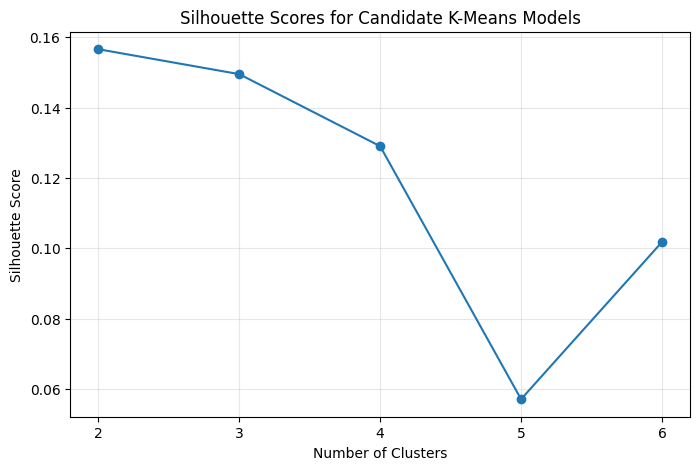

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_evaluation_df["Number of Clusters"],
    cluster_evaluation_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Candidate K-Means Models")
plt.xticks(cluster_evaluation_df["Number of Clusters"])
plt.grid(True, alpha=0.3)
plt.show()

The silhouette score measures whether students appear relatively close to members of their own cluster and separated from other clusters. Values closer to 1 indicate stronger separation; values closer to 0 indicate overlapping clusters.

We will use
```
n_clusters=3
```
Although the two-cluster model produced the highest silhouette score, the three-cluster model performed similarly while providing additional segmentation for exploratory analysis. Overall silhouette scores being relatively low suggests that the student profiles do not separate into clearly defined groups. We will revisit this as additional data becomes available.

In [37]:
# Fit the n_clusters=3 K-Means model

final_k = 3

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

student_cluster_results["Cluster"] = final_kmeans.fit_predict(
    X_students
)

student_cluster_results[
    ["Student ID", "Student Name", "Cluster"]
].head()

,Student ID,Student Name,Cluster
0,ST-uZFp9,STA,0
1,ST-2,STB,0
2,ST-1,STC,0
3,ST-3,STD,2
4,ST-jPyn5,STE,0


In [38]:
# Count the number of students assigned to each cluster

cluster_sizes = (
    student_cluster_results["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Number of Students")
)

cluster_sizes

,Cluster,Number of Students
0,0,15
1,1,4
2,2,7


This model may be isolating a few unusual profiles in cluster 1 instead of finding three useful segments.

In [39]:
cluster_sizes["Percent of Students"] = (
    cluster_sizes["Number of Students"]
    / cluster_sizes["Number of Students"].sum()
    * 100
).round(1)

cluster_sizes

,Cluster,Number of Students,Percent of Students
0,0,15,57.7
1,1,4,15.4
2,2,7,26.9


In [42]:
# Display students grouped by cluster

for cluster_number in sorted(
    student_cluster_results["Cluster"].unique()
):
    print(f"\nCLUSTER {cluster_number}")
    print("-" * 30)

    cluster_students = student_cluster_results.loc[
        student_cluster_results["Cluster"] == cluster_number,
        ["Student Name"]
    ]

    print(cluster_students.to_string(index=False))


CLUSTER 0
------------------------------
Student Name
         STA
         STB
         STC
         STE
         STI
         STJ
         STN
         STS
         STT
         STU
         STV
         STW
         STX
         STY
         STZ

CLUSTER 1
------------------------------
Student Name
         STM
         STO
         STP
         STQ

CLUSTER 2
------------------------------
Student Name
         STD
         STF
         STG
         STH
         STK
         STL
         STR


After generating the clusters, I compared them against the original (non-anonymized) dataset to look for obvious patterns.

At first, no consistent trends immediately stood out. That suggests the current feature set may not be capturing the best characteristics for distinguishing groups of students, or that additional feature engineering may be needed before the clusters become more interpretable.

In [43]:
# Get the vocabulary created by the TF-IDF vectorizer

feature_names = vectorizer.get_feature_names_out()

# Rank the terms in each cluster from highest to lowest weight.
sorted_term_indices = final_kmeans.cluster_centers_.argsort(
    axis=1
)[:, ::-1]

top_terms_per_cluster = []

for cluster_number in range(final_k):
    top_indices = sorted_term_indices[cluster_number, :15]
    top_terms = feature_names[top_indices]

    top_terms_per_cluster.append({
        "Cluster": cluster_number,
        "Top Terms": ", ".join(top_terms)
    })

cluster_terms_df = pd.DataFrame(top_terms_per_cluster)

cluster_terms_df

,Cluster,Top Terms
0,0,"student, academic, support, tutoring, act, sch..."
1,1,"gaming, visual, auditory, general, independent..."
2,2,"school, grade, student, adhd, didn, really, 10..."


In [44]:
# Review the student profiles assigned to each cluster

for cluster_number in range(final_k):
    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_number}")
    print("=" * 80)

    cluster_profiles = student_cluster_results.loc[
        student_cluster_results["Cluster"] == cluster_number,
        ["Student Name", "StudentProfile"]
    ]

    for _, row in cluster_profiles.iterrows():
        print(f"\nStudent: {row['Student Name']}")
        print(row["StudentProfile"][:500])
        print("-" * 80)


CLUSTER 0

Student: STA
College consulting for competitive high school volleyball player Summary
The meeting focused on planning and strategizing for Student's college admissions process, with a particular emphasis on balancing her academic ambitions, athletic commitments (especially volleyball), and extracurricular activities. The family, along with the advisor, discussed Student's goal of attending a high academic institution such as Stanford, ideally as a student-athlete, and possibly pursuing a pre-med or STEM trac
--------------------------------------------------------------------------------

Student: STB
School: New York area
Subject: 10th grade Geometry
Specific topics: Circles, Pythagorean theorem, proofs, polygons, trigonometry, perpendicular bisectors, triangle centers, angle puzzles
Timeline: Urgent — needs support now through finals
Format: Virtual preferred
Goal: Get caught up and prepared for final exam
Notes: Quick learner, diligent student — gaps are specific and coa

## Initial Observations

A few patterns stood out after reviewing the first clustering results.

Cluster 1 generally contains shorter profile descriptions. Profile length may influence the clustering.

I also expected one cluster to contain a larger proportion of neurodivergent students. After comparing the clusters to the original dataset, that pattern did not hold.

The highest-weighted terms are also dominated by common education-related words such as
- student,
- school,
- academic,
- grade, and
- tutoring.

Before interpreting these clusters further, I would like to repeat the analysis after removing these domain-specific terms to determine whether more meaningful groupings emerge.

Finally, I would like to identify the students closest to each cluster center. Those students should provide the clearest examples of the characteristics represented by each cluster.

In [48]:
# Combine the cluster statistics into one summary table.

cluster_summary = cluster_sizes.merge(
    cluster_terms_df,
    on="Cluster",
    how="left"
)

cluster_summary

,Cluster,Number of Students,Percent of Students,Top Terms
0,0,15,57.7,"student, academic, support, tutoring, act, sch..."
1,1,4,15.4,"gaming, visual, auditory, general, independent..."
2,2,7,26.9,"school, grade, student, adhd, didn, really, 10..."


In [45]:
# Calculate each student's distance from every cluster center

distances_to_centers = final_kmeans.transform(X_students)

# Record the distance to the center of the student's assigned cluster

student_cluster_results["Distance to Cluster Center"] = [
    distances_to_centers[row_index, cluster_number]
    for row_index, cluster_number
    in enumerate(student_cluster_results["Cluster"])
]

# Smaller distances indicate a more "representative" cluster member

representative_students = (
    student_cluster_results[
        [
            "Cluster",
            "Student Name",
            "Distance to Cluster Center"
        ]
    ]
    .sort_values(
        ["Cluster", "Distance to Cluster Center"]
    )
    .groupby("Cluster")
    .head(3)
    .reset_index(drop=True)
)

representative_students

,Cluster,Student Name,Distance to Cluster Center
0,0,STX,0.632033
1,0,STV,0.683099
2,0,STJ,0.699621
3,1,STO,0.631545
4,1,STP,0.733290
5,1,STM,0.758450
6,2,STL,0.778245
7,2,STG,0.826907
8,2,STH,0.853084


In [47]:
# Summarize the distance from each student to the center
# of their assigned cluster.

distance_summary = (
    student_cluster_results
    .groupby("Cluster")["Distance to Cluster Center"]
    .agg(
        Mean_Distance="mean",
        Standard_Deviation="std",
        Minimum_Distance="min",
        Maximum_Distance="max",
        Number_of_Students="count"
    )
    .round(3)
)

distance_summary

,Mean_Distance,Standard_Deviation,Minimum_Distance,Maximum_Distance,Number_of_Students
Cluster,,,,,
0,0.770,0.099,0.632,1.015,15
1,0.728,0.068,0.632,0.788,4
2,0.861,0.046,0.778,0.906,7


## Initial Conclusions

This first clustering model produced three student groups of different sizes. Cluster 0 contains most of the students (57.7%), while Clusters 1 and 2 represent smaller segments of the dataset.

The average distance to each cluster center provides a rough measure of how similar students are to the other members of their assigned cluster. Cluster 1 has the smallest average distance (0.728), suggesting that its students are the most internally similar. Cluster 2 has the largest average distance (0.861), suggesting that those students are more varied and may not represent as cohesive a group.

Overall, the clusters were not immediately interpretable when compared to the original student records. The silhouette scores were also relatively low, indicating that the student profiles do not separate into strongly defined groups using the current feature set.

While this clustering model is exploratory, it suggests one possible direction for improving the recommendation engine. If meaningful student segments emerge through future iterations, those clusters could eventually become additional features in the tutor matching model or inform how tutoring services are assigned. Rather than treating this as a final model, I see it as a baseline. It establishes a clustering workflow that I can refine through additional feature engineering and compare against future iterations.

## Next Steps

The next iteration of this model will focus on improving the input features rather than changing the clustering algorithm.

Specifically, I would like to:

- Remove common education-related terms such as *student*, *school*, *academic*, *grade*, and *tutoring* so the model places more emphasis on characteristics that distinguish students.
- Compare the new clusters against this baseline to determine whether they become more interpretable.
- Continue investigating whether profile length influenced the clustering.
- Evaluate additional clustering approaches and dimensionality reduction techniques if the current feature engineering does not produce clearer student segments.

For now, this notebook establishes an initial unsupervised baseline that future iterations can be measured against.